<a href="https://colab.research.google.com/github/vsauldba/python-data-analytics/blob/main/Diabetes_Patient_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clinical endpoint analysis in diabetes research

## Step 1-: Project Introduction

Diabetes is a chronic condition that can affect patient health and healthcare utilization. This project analyzes hospital data from patients with diabetes to identify patterns in patient care and outcomes.


### Research Question
What patient and hospital factors are associated with outcomes among hospitalized patients with diabetes?



**Step 2: Data Source**

This project uses the **Diabetes 130-US Hospitals for Years 1999-2008** dataset from the **UCI Machine Learning Repository**. The dataset contains hospital encounter information for patients with diabetes and includes demographic, clinical, treatment, and hospital utilization variables.

**Step 3: Import the Libraries**


In [ ]:
# Import libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Step 4: Upload the Dataset from Google Colab**

In [ ]:
# Upload the dataset to Google Colab
from google.colab import files
uploaded = files.upload()

Saving csv_diabetic_files.csv to csv_diabetic_files.csv


**Step 5 — Load the Dataset**


In [ ]:
# Load the diabetes dataset
df = pd.read_csv("csv_diabetic_files.csv")

**Step 6 — Preview the Dataset**

In [ ]:
# Display the first five rows

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Step 7 — Check the dataset size**

In [ ]:
# Check the number of rows and columns
rows, columns = df.shape
print("Rows:", rows)
print("Columns:", columns)

Rows: 101766
Columns: 50


### Step 7- Dataset Structure

The dataset contains  101766 Rows and 50 Columns. Each Rows represents a patient encounter, while the Columns contain different patient and healthcare-related information.
The dataset dimensions were examined to understand the number of observations and variables available for analysis.

**Step 8 — Check the Column Names**

Now we need to understand what information is available before we start cleaning.

In [ ]:
# Display all column names
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

**Step 9 — Check Data Types and Dataset Information**

In [ ]:
# Check dataset information and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

### Observation

The dataset contains 101,766 records and 50 columns, with 13 numerical columns and 37 categorical columns. Most variables are complete, while `max_glu_serum` and `A1Cresult` contain substantial missing values. Further data-quality checks are needed because some missing values may also be represented by `"?"`.

**Step 10: Check Missing Values Properly**

In [ ]:
# Check standard missing values
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
# Check for missing values represented by "?"
(df == "?").sum().sort_values(ascending=False).head(10)

,0
weight,98569
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
admission_type_id,0
patient_nbr,0
encounter_id,0


### Missing Values Observation

The dataset contains both standard missing values and missing values represented by "?". The largest amount of missing data appears in weight, max_glu_serum, A1Cresult, medical_specialty, and payer_code. These values will be handled carefully during data cleaning to avoid removing useful patient records unnecessarily.

**Step 11: Check Duplicates Records**

In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Duplicate Records Observation
No duplicate rows were found in the dataset. Therefore, no records need to be removed based on full-row duplication.

**Step 12 — Descriptive Statistics**

Before changing the data, let's understand the numerical variables that's describe  the main features of the dataset.

In [ ]:
# Generate descriptive statistics for numerical variables
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Descriptive Statistics Observation

The numerical summary provides an overview of hospital utilization and patient encounter variables. The average hospital stay was approximately 4.4 days, with a median of 4 days and a range of 1 to 14 days. Identifier and coded categorical variables will not be interpreted as continuous numerical measures.

**Step 13 — Create a Clean Copy**

## Data Cleaning and Transformation
A copy of the original dataset was created before cleaning to preserve the raw data. Missing values, unnecessary variables, and data quality issues will be addressed before analysis.

In [ ]:
# Create a copy of the original dataset for cleaning
df_clean = df.copy()

# Check the shape of the copied dataset
df_clean.shape

(101766, 50)

**Step 14 — Convert "?" to Missing Values**

We discovered that several columns use "?" to represent missing information. Let's convert those to proper NaN values so Pandas recognizes them correctly.

In [ ]:
# Convert question marks to standard missing values
df_clean.replace("?", np.nan, inplace=True)

In [ ]:
# Display columns with the most missing values
df_clean.isnull().sum().sort_values(ascending=False).head(10)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


### Missing Data Observation

After converting `"?"` values to standard missing values, several columns showed substantial missingness. The highest levels were found in `weight`, `max_glu_serum`, `A1Cresult`, `medical_specialty`, and `payer_code`. These variables will be reviewed carefully before deciding whether to keep, remove, or transform them.

 **Check missing-value percentages**

Before dropping anything, let's calculate the percentage of missing values.

In [ ]:
# Calculate missing-value percentages
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_percent.sort_values(ascending=False).head(10)

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
patient_nbr,0.000000


### Missing Value Percentage Observation

The analysis shows that `weight`, `max_glu_serum`, and `A1Cresult` have more than 80% missing values. Because these variables contain insufficient information for reliable analysis, they will be removed from the cleaned dataset. Other variables with lower levels of missingness will be handled separately based on their relevance to the research question.

## Let's remove theses three extremely incomplete columns
such as:
- weight
- max_glu_serum
- A1Cresult
We won't automatically remove medical_specialty or payer_code just because they have missing values; we'll decide based on whether we need them.

In [ ]:
# Remove columns with more than 80% missing values
df_clean = df_clean.drop(
    columns=['weight', 'max_glu_serum', 'A1Cresult']
)

# Confirm the new dataset shape
df_clean.shape

(101766, 47)

### Cleaning Observation

Three columns with more than 80% missing values were removed. The cleaned dataset now contains 101,766 records and 47 variables.

**Handle Remaining Missing Values**

Before changing anything else, let's see which columns still contain missing values.

In [ ]:
# Check remaining missing values
remaining_missing = df_clean.isnull().sum()

remaining_missing[remaining_missing > 0].sort_values(ascending=False)

,0
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


**Step 15 — Handle Remaining Missing Values**

For categorical fields such as medical_specialty, payer_code, and race, we can preserve the records and label missing information as Unknown.
For the diagnosis fields (diag_1, diag_2, diag_3), we'll also use Unknown so we don't lose entire hospital encounters.


In [ ]:
# Fill remaining missing categorical values with "Unknown"

columns_to_fill = [
    'medical_specialty',
    'payer_code',
    'race',
    'diag_1',
    'diag_2',
    'diag_3'
]

df_clean[columns_to_fill] = df_clean[columns_to_fill].fillna('Unknown')

In [ ]:
## Let's verify if no missing values remain
df_clean.isnull().sum().sum()

np.int64(0)

### Missing Data Treatment

Missing categorical values were labeled as `Unknown` to preserve hospital encounter records. After treatment, no missing values remained in the cleaned dataset.

**Select Variables for Analysis**

Now we should not analyze all 47 columns. We need a focused analytical dataset that matches your research


## Variable Selection

Relevant demographic, clinical, treatment, and outcome variables were selected for further analysis.

In [ ]:
# Identifying relevant variables for the analysis

analysis_columns = [
    'race',
    'gender',
    'age',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'insulin',
    'change',
    'diabetesMed',
    'readmitted'
]

df_analysis = df_clean[analysis_columns].copy()

# Check the new dataset
df_analysis.shape

(101766, 15)

### Variable Selection Observation

Fifteen relevant variables were selected for the analysis, including patient demographics, hospital utilization, treatment information, and readmission outcomes. This focused dataset will be used for exploratory and statistical analysis.

Step 16 — Exploratory Data Analysis (EDA)
Now we're ready to explore the data. Start with our main outcome variable: readmitted.

## Exploratory Data Analysis

Exploratory data analysis was conducted to understand patient characteristics, hospital utilization, treatment patterns, and readmission outcomes.

In [ ]:
# Examine the distribution of readmission outcomes
df_analysis['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


### Readmission Percentage Observation

More than half of the hospital encounters (53.91%) did not result in readmission. About 34.93% were readmitted after more than 30 days, while 11.16% were readmitted within 30 days.

**Step 17 — Calculate Readmission Percentages**

Counts are useful, but percentages will make the result easier to interpret.

In [ ]:
# Calculate readmission percentages
readmission_percent = (
    df_analysis['readmitted']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmission_percent

,proportion
readmitted,
NO,53.91
>30,34.93
<30,11.16


### Readmission Percentage Observation

More than half of the hospital encounters (53.91%) did not result in readmission. About 34.93% were readmitted after more than 30 days, while 11.16% were readmitted within 30 days.

Step 18 — Create, First Professional Visualization

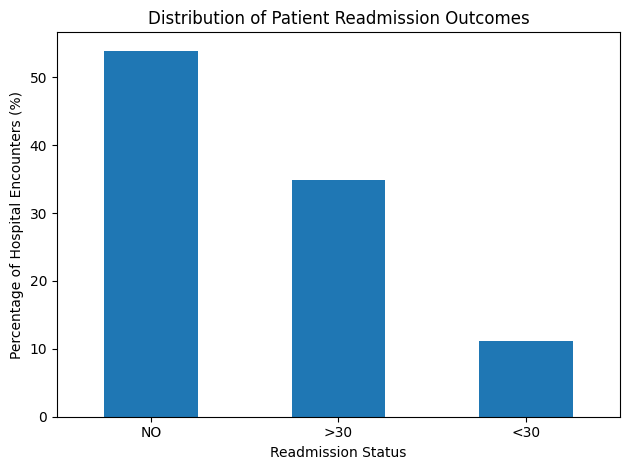

In [ ]:
# Visualize readmission outcomes

readmission_percent.plot(kind='bar')

plt.title('Distribution of Patient Readmission Outcomes')
plt.xlabel('Readmission Status')
plt.ylabel('Percentage of Hospital Encounters (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

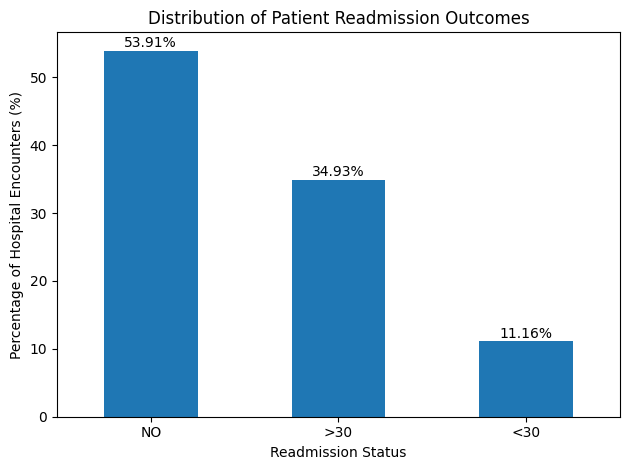

In [ ]:
# Visualize readmission outcomes

ax = readmission_percent.plot(kind='bar')

plt.title('Distribution of Patient Readmission Outcomes')
plt.xlabel('Readmission Status')
plt.ylabel('Percentage of Hospital Encounters (%)')
plt.xticks(rotation=0)

# Add percentage labels
for i, value in enumerate(readmission_percent):
    plt.text(i, value + 0.5, f'{value:.2f}%', ha='center')

plt.tight_layout()
plt.show()

### Key Finding

The majority of hospital encounters (53.91%) did not result in readmission. Readmission after more than 30 days accounted for 34.93% of encounters, while 11.16% were readmitted within 30 days.

Step 19 — Analyze Patient Age Distribution
Age is already grouped in the dataset ([0-10), [10-20), etc.).

In [ ]:
# Examine the distribution of patients by age group

age_counts = df_analysis['age'].value_counts().sort_index()

age_counts

,count
age,
[0-10),161
[10-20),691
[20-30),1657
[30-40),3775
[40-50),9685
[50-60),17256
[60-70),22483
[70-80),26068
[80-90),17197


In [ ]:
# Calculate the percentage of hospital encounters by age group

age_percent = (
    df_analysis['age']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

age_percent

,proportion
age,
[0-10),0.16
[10-20),0.68
[20-30),1.63
[30-40),3.71
[40-50),9.52
[50-60),16.96
[60-70),22.09
[70-80),25.62
[80-90),16.90


Step 20- Create Age visualization

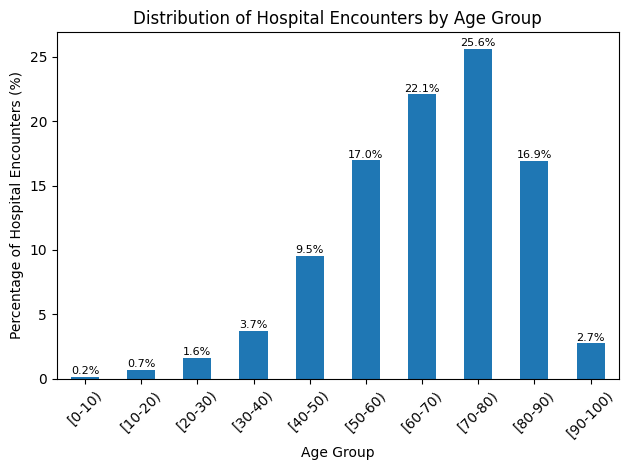

In [ ]:
# Visualize hospital encounters by age group

ax = age_percent.plot(kind='bar')

plt.title('Distribution of Hospital Encounters by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Hospital Encounters (%)')
plt.xticks(rotation=45)

for i, value in enumerate(age_percent):
    plt.text(i, value + 0.2, f'{value:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### Age Distribution Observation

Hospital encounters were concentrated among older patients. The [70–80) age group represented the largest proportion of encounters (approximately 25.6%), followed by the [60–70) age group (approximately 22.1%).

In [ ]:
# Displays readmission outcomes across age groups

age_readmission = pd.crosstab(
    df_analysis['age'],
    df_analysis['readmitted'],
    normalize='index'
) * 100

age_readmission = age_readmission.round(2)

age_readmission

readmitted,<30,>30,NO
age,,,
[0-10),1.86,16.15,81.99
[10-20),5.79,32.42,61.79
[20-30),14.24,30.78,54.98
[30-40),11.23,31.44,57.32
[40-50),10.60,33.85,55.55
[50-60),9.67,34.29,56.04
[60-70),11.13,35.12,53.75
[70-80),11.77,36.35,51.88
[80-90),12.08,36.19,51.73


### Age and Readmission Observation

Readmission patterns varied by age groups. Older patient groups generally showed higher readmission percentages than younger groups, suggesting that age may be associated with hospital readmission outcomes.

**Step 21 — Visualize Age vs. Readmission**

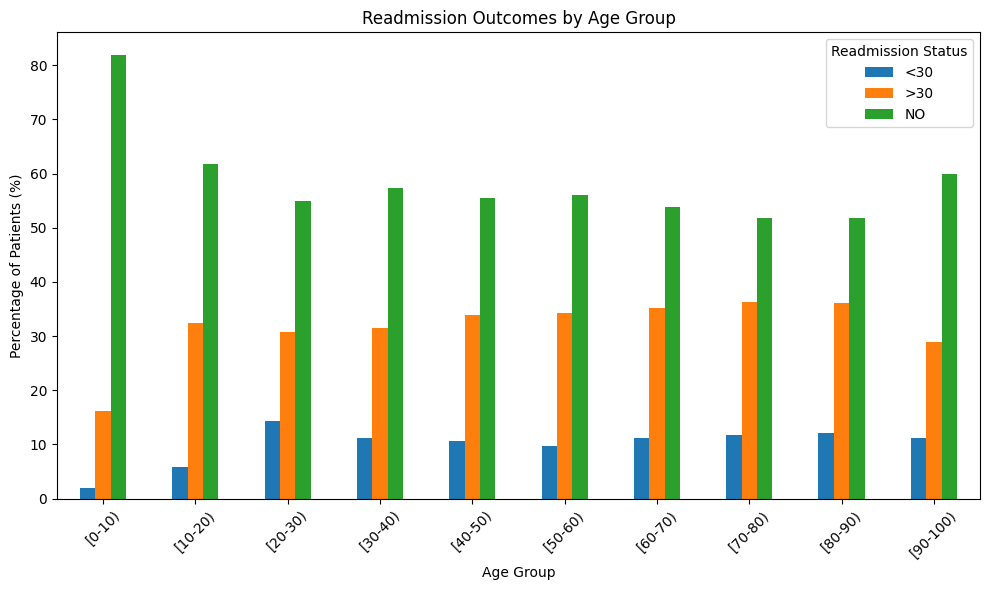

In [ ]:
# Visualize readmission outcomes by age group

age_readmission.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Readmission Outcomes by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Patients (%)')
plt.xticks(rotation=45)
plt.legend(title='Readmission Status')
plt.tight_layout()
plt.show()

### Age and Readmission Analysis

The chart shows that readmission outcomes vary by age groups. No readmission remains the most common outcome in every age group, while readmission percentages differ across age categories. Older age groups generally show a higher proportion of readmissions compared with the youngest groups.

**Step 22 — Length of Hospital Stay vs. Readmission**

In [ ]:
# Calculate average hospital stay by readmission status

stay_by_readmission = (
    df_analysis.groupby('readmitted')['time_in_hospital']
    .mean()
    .round(2)
)

stay_by_readmission

,time_in_hospital
readmitted,
<30,4.77
>30,4.50
NO,4.25


### Hospital Stay and Readmission Analysis

Patients readmitted within 30 days had the longest average hospital stay at 4.77 days, compared with 4.50 days for patients readmitted after 30 days and 4.25 days for patients who were not readmitted. This suggests a possible relationship between length of stay and readmission outcome.

**Step 23 — Visualize the result**

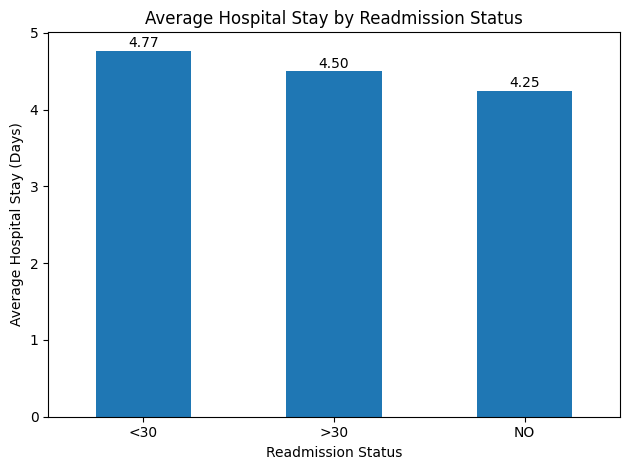

In [ ]:
# Visualize average hospital stay by readmission status

ax = stay_by_readmission.plot(kind='bar')

plt.title('Average Hospital Stay by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Average Hospital Stay (Days)')
plt.xticks(rotation=0)

# Add value labels
for i, value in enumerate(stay_by_readmission):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

### Hospital Stay and Readmission Analysis

Patients readmitted within 30 days had the longest average hospital stay at 4.77 days, followed by patients readmitted after 30 days at 4.50 days. Patients who were not readmitted had the shortest average stay at 4.25 days.

Step 24 — Number of Medications vs. Readmission
First, calculate the average number of medications for each readmission group.




In [ ]:
# Calculate average number of medications by readmission status

medications_by_readmission = (
    df_analysis.groupby('readmitted')['num_medications']
    .mean()
    .round(2)
)

medications_by_readmission

,num_medications
readmitted,
<30,16.90
>30,16.28
NO,15.67


### Medication Use and Readmission Analysis

Patients readmitted within 30 days had the highest average number of medications (16.90), followed by patients readmitted after 30 days (16.28). Patients who were not readmitted had the lowest average at 15.67 medications.

**Step 25: Visualization of medication Uses**

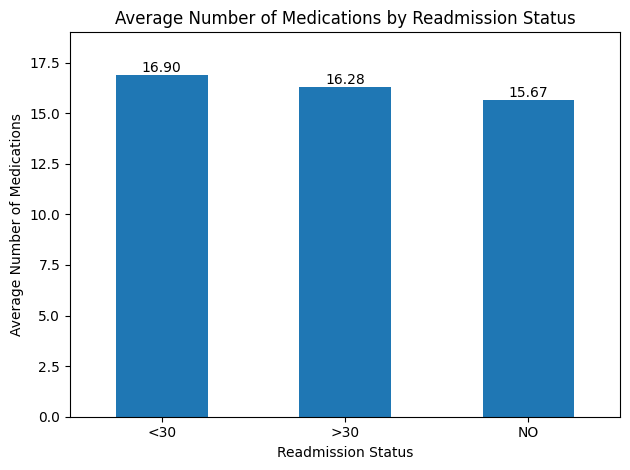

In [ ]:
# Visualize average number of medications by readmission status

ax = medications_by_readmission.plot(kind='bar')

plt.title('Average Number of Medications by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Average Number of Medications')
plt.xticks(rotation=0)

# Add value labels
for i, value in enumerate(medications_by_readmission):
    plt.text(i, value + 0.15, f'{value:.2f}', ha='center')

plt.ylim(0, 19)
plt.tight_layout()
plt.show()

**Step 26 — Inferential Statistical Analysis**

We'll test whether age group and readmission status are statistically associated. Because both variables are categorical, a Chi-Square Test of Independence is appropriate.

## Inferential Statistical Analysis

A Chi-Square Test of Independence was conducted to determine whether there is a statistically significant association between patient age group and readmission status.

In [ ]:
# Import the Chi-Square test
from scipy.stats import chi2_contingency

# Create a contingency table
age_readmission_table = pd.crosstab(
    df_analysis['age'],
    df_analysis['readmitted']
)

# Perform the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(age_readmission_table)

print("Chi-Square Statistic:", round(chi2, 2))
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 313.17
P-value: 9.348415309480624e-56
Degrees of Freedom: 18


### Chi-Square Test Interpretation

The Chi-Square test produced a p-value below 0.05, indicating a statistically significant association between patient age group and readmission status. Therefore, readmission patterns differ across age groups in this dataset.

This result indicates an association, not a causal relationship.

We've completed the major technical requirements: data inspection → missing-data treatment → transformations → variable selection → descriptive statistics → EDA → visualizations → inferential statistics.

Step 27 — Key Findings, where we'll summarize the strongest results from your actual analysis. Then we'll write the final conclusion.

## Key Findings

The analysis identified several important patterns in diabetes-related hospital encounters:

- **Readmission:** 53.91% of encounters did not result in readmission, while 34.93% were readmitted after 30 days and 11.16% were readmitted within 30 days.
- **Age:** Hospital encounters were concentrated among older patients, with the (70–80) age group representing the largest proportion of encounters.
- **Length of Stay:** Patients readmitted within 30 days had the longest average hospital stay at 4.77 days, compared with 4.50 days for readmission after 30 days and 4.25 days for no readmission.
- **Medication Use:** Patients readmitted within 30 days had the highest average number of medications at 16.90, compared with 16.28 for readmission after 30 days and 15.67 for no readmission.
- **Statistical Analysis:** The Chi-Square test found a statistically significant association between age group and readmission status (χ² = 313.17, p < 0.05).

**Step 28 — Conclusion**


## Conclusion

This analysis found that patient outcomes varied across demographic and hospital-related factors. Patients readmitted within 30 days had slightly longer hospital stays and used more medications on average than patients who were not readmitted.

Age group was also significantly associated with readmission status. These findings suggest that age, hospital utilization, and treatment characteristics may be useful factors when examining readmission patterns among hospitalized patients with diabetes.

The results show associations within this dataset and should not be interpreted as evidence of causation.

**Step 29 — Final Dataset Validation**

In [ ]:
# Final validation of the analysis dataset

print("Rows:", df_analysis.shape[0])
print("Columns:", df_analysis.shape[1])
print("Missing Values:", df_analysis.isnull().sum().sum())
print("Duplicate Rows:", df_analysis.duplicated().sum())

Rows: 101766
Columns: 15
Missing Values: 0
Duplicate Rows: 81


### Final Data Validation

The final analysis dataset contains 101,766 records and 15 selected variables with no missing values. Although 81 duplicate-looking rows were identified in the reduced dataset, they were retained because the original dataset contained no duplicate records. These similarities occurred after selecting a smaller set of analytical variables.

**Step 30: References**
- UCI Machine Learning Repository. *Diabetes 130-US Hospitals for Years 1999–2008.*
- Python Documentation
- Pandas Documentation
- NumPy Documentation
- Matplotlib Documentation
- SciPy Documentation
- OpenAI ChatGPT — Used for coding assistance, project organization, and documentation support.
- Microsoft Copilot — AI-assisted research and documentation support.